In [4]:
pip install numpy pandas cvxpy scipy matplotlib seaborn


          AURA INSTITUTIONAL METRICS TEAR-SHEET (CANADA ACB)          
Metric                    | Benchmark    | Strategy (Pre) | Strategy (Post)
----------------------------------------------------------------------
Total Return              |       12.34% |         17.57% |         18.96%
Annualized Volatility     |       19.45% |         19.43% |         19.16%
Sharpe Ratio              |        0.53  |          0.80  |          0.89 
Max Drawdown              |      -17.62% |        -16.70% |        -15.69%
----------------------------------------------------------------------
Tax Alpha Generated       |            - |              - |          1.39%
Realized Tracking Error   |            - |          2.03% |              -
Beta to Benchmark         |         1.00 |          1.00  |              -
Information Ratio         |            - |          2.57  |              -


[INFO] Dashboard image successfully saved to 'img/dashboard.png'


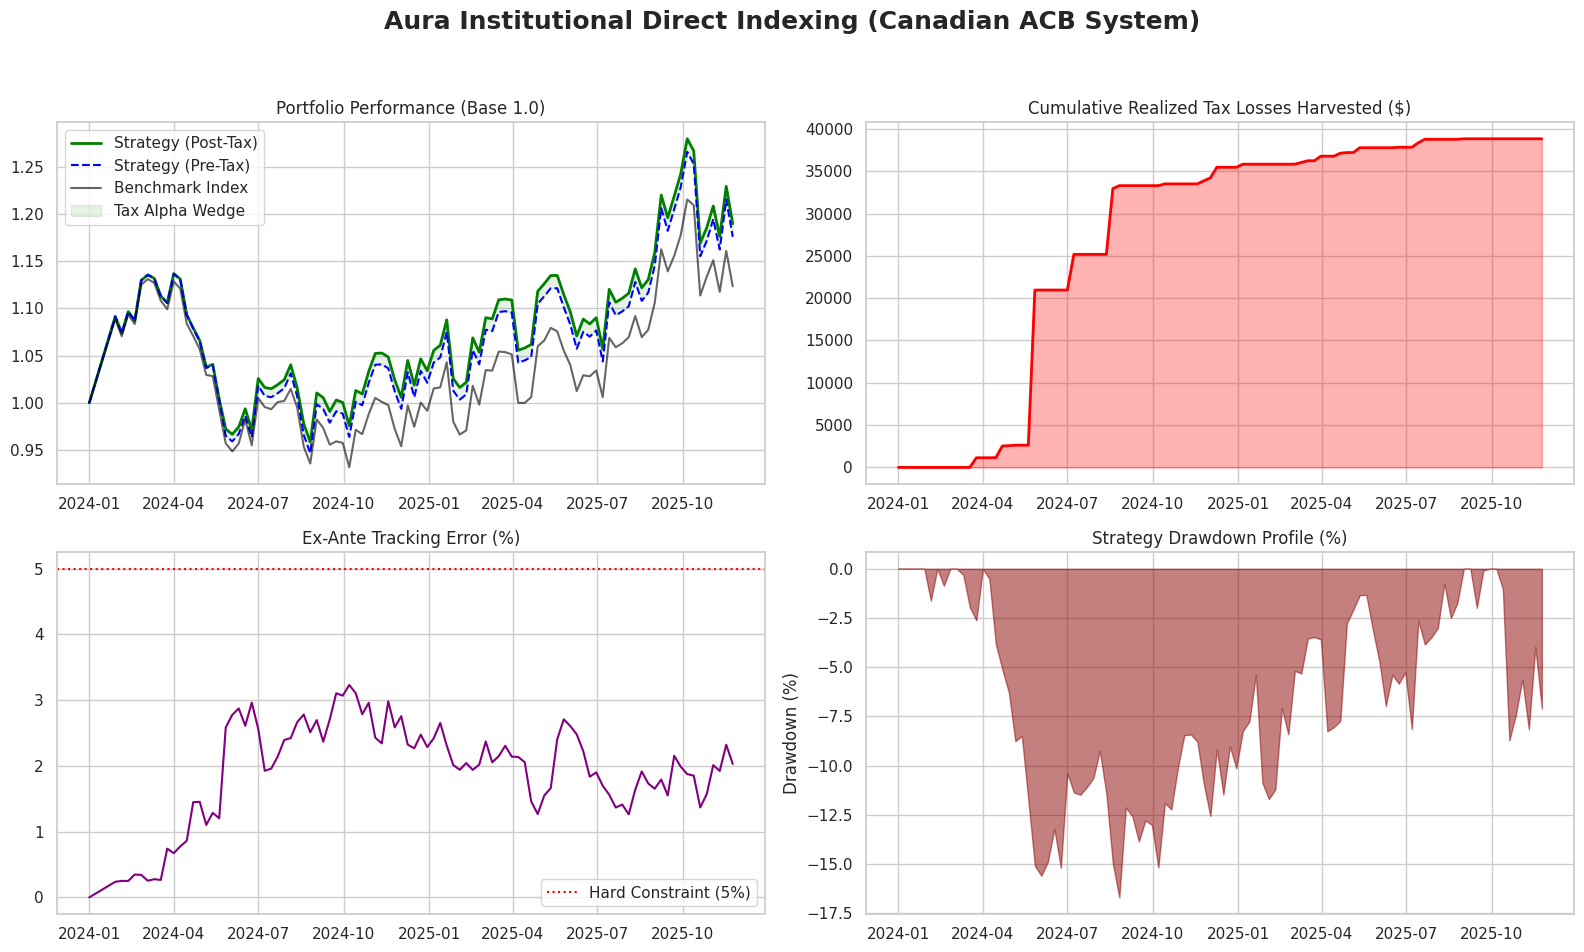

In [17]:
#CANADA

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os

# Set plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. ROBUST TAX LEDGER (CASH + CANADIAN ACB + WASH SALE)
# ==========================================

class CanadianTaxLedger:
    def __init__(self, initial_cash=0.0):
        self.cash = initial_cash
        self.shares = defaultdict(float)
        self.acb_total = defaultdict(float)
        self.realized_gains = 0.0
        self.realized_losses = 0.0
        self.lockouts = defaultdict(int)

    def buy(self, ticker, shares_bought, price, current_step=None):
        if shares_bought <= 1e-6: return
        cost = shares_bought * price
        self.cash -= cost
        self.shares[ticker] += shares_bought
        self.acb_total[ticker] += cost

    def sell(self, ticker, shares_sold, current_price, current_step=None):
        if shares_sold <= 1e-6 or self.shares[ticker] <= 1e-6: return
        shares_sold = min(shares_sold, self.shares[ticker])

        # CRA Rule: Average Cost Base
        acb_per_share = self.acb_total[ticker] / self.shares[ticker]

        cost_of_goods_sold = shares_sold * acb_per_share
        proceeds = shares_sold * current_price
        pnl = proceeds - cost_of_goods_sold

        if pnl > 0:
            self.realized_gains += pnl
        else:
            self.realized_losses += abs(pnl)
            self.lockouts[ticker] = 30 # CRA 30-Day Superficial Loss Lockout

        self.cash += proceeds
        self.shares[ticker] -= shares_sold
        self.acb_total[ticker] -= cost_of_goods_sold

    def update_lockouts(self, days_passed):
        for ticker in list(self.lockouts.keys()):
            if self.lockouts[ticker] > 0:
                self.lockouts[ticker] -= days_passed
                if self.lockouts[ticker] < 0:
                    self.lockouts[ticker] = 0

    def get_unrealized_loss_percentage(self, ticker, current_price):
        if self.shares[ticker] <= 1e-6: return 0.0
        acb_per_share = self.acb_total[ticker] / self.shares[ticker]
        if acb_per_share > current_price:
            return (acb_per_share - current_price) / acb_per_share
        return 0.0

    def is_locked(self, ticker):
        return self.lockouts[ticker] > 0

# ==========================================
# 2. CONSTRAINED CONVEX OPTIMIZER
# ==========================================

class RobustOptimizer:
    def __init__(self, num_assets, lambda_tc=0.005, lambda_tax=0.15):
        self.N = num_assets
        self.lambda_tc = lambda_tc
        self.lambda_tax = lambda_tax

    def optimize(self, w_current, w_benchmark, cov_matrix, unrealized_losses, locked_flags):
        w = cp.Variable(self.N)
        cov_matrix = cov_matrix + np.eye(self.N) * 1e-6
        te_variance = cp.quad_form(w - w_benchmark, cov_matrix)

        delta_w = w - w_current
        turnover_penalty = self.lambda_tc * cp.norm(delta_w, 1)
        tax_incentive = self.lambda_tax * (unrealized_losses.T @ delta_w)

        objective = cp.Minimize(te_variance + turnover_penalty + tax_incentive)

        constraints =[
            cp.sum(w) == 1,
            w >= 0,
            cp.abs(w - w_benchmark) <= 0.05
        ]

        # Enforce CRA Superficial Loss lockouts directly into the optimizer
        for i in range(self.N):
            if locked_flags[i]:
                constraints.append(w[i] <= w_current[i] + 1e-5)

        prob = cp.Problem(objective, constraints)

        try:
            prob.solve(solver=cp.OSQP)
            if w.value is None: return w_current
            return w.value
        except:
            return w_current

# ==========================================
# 3. METRICS TEAR-SHEET
# ==========================================

def calculate_drawdown(series):
    roll_max = series.cummax()
    return ((series - roll_max) / roll_max).min()

def print_metrics_tearsheet(df_history):
    print("\n" + "="*70)
    print(f"{'AURA INSTITUTIONAL METRICS TEAR-SHEET (CANADA ACB)':^70}")
    print("="*70)

    strat_pre_ret = df_history['pre_tax_val'].pct_change().dropna()
    strat_post_ret = df_history['post_tax_val'].pct_change().dropna()
    bench_ret = df_history['bench_val'].pct_change().dropna()

    ann_pre = (df_history['pre_tax_val'].iloc[-1] / df_history['pre_tax_val'].iloc[0]) - 1
    ann_post = (df_history['post_tax_val'].iloc[-1] / df_history['post_tax_val'].iloc[0]) - 1
    ann_bench = (df_history['bench_val'].iloc[-1] / df_history['bench_val'].iloc[0]) - 1

    # FIX: Annualization factor for weekly steps (252 / 5)
    ann_factor = np.sqrt(252 / 5)
    vol_pre = strat_pre_ret.std() * ann_factor
    vol_post = strat_post_ret.std() * ann_factor
    vol_bench = bench_ret.std() * ann_factor

    rf = 0.02
    sharpe_pre = (ann_pre - rf) / vol_pre if vol_pre > 0 else 0
    sharpe_post = (ann_post - rf) / vol_post if vol_post > 0 else 0
    sharpe_bench = (ann_bench - rf) / vol_bench if vol_bench > 0 else 0

    dd_pre = calculate_drawdown(df_history['pre_tax_val'])
    dd_post = calculate_drawdown(df_history['post_tax_val'])
    dd_bench = calculate_drawdown(df_history['bench_val'])

    tracking_error = strat_pre_ret.sub(bench_ret).std() * ann_factor
    info_ratio = (ann_pre - ann_bench) / tracking_error if tracking_error > 0 else 0
    tax_alpha = ann_post - ann_pre

    # FIX: Guard against dividing by zero if benchmark variance is 0
    var_bench = np.var(bench_ret)
    beta = np.cov(strat_pre_ret, bench_ret)[0][1] / var_bench if var_bench > 0 else 1.0

    print(f"{'Metric':<25} | {'Benchmark':<12} | {'Strategy (Pre)':<14} | {'Strategy (Post)':<14}")
    print("-" * 70)
    print(f"{'Total Return':<25} | {ann_bench*100:>11.2f}% | {ann_pre*100:>13.2f}% | {ann_post*100:>13.2f}%")
    print(f"{'Annualized Volatility':<25} | {vol_bench*100:>11.2f}% | {vol_pre*100:>13.2f}% | {vol_post*100:>13.2f}%")
    print(f"{'Sharpe Ratio':<25} | {sharpe_bench:>11.2f}  | {sharpe_pre:>13.2f}  | {sharpe_post:>13.2f} ")
    print(f"{'Max Drawdown':<25} | {dd_bench*100:>11.2f}% | {dd_pre*100:>13.2f}% | {dd_post*100:>13.2f}%")
    print("-" * 70)
    print(f"{'Tax Alpha Generated':<25} | {'-':>12} | {'-':>14} | {tax_alpha*100:>13.2f}%")
    print(f"{'Realized Tracking Error':<25} | {'-':>12} | {tracking_error*100:>13.2f}% | {'-':>14}")
    print(f"{'Beta to Benchmark':<25} | {'1.00':>12} | {beta:>13.2f}  | {'-':>14}")
    print(f"{'Information Ratio':<25} | {'-':>12} | {info_ratio:>13.2f}  | {'-':>14}")
    print("="*70 + "\n")

# ==========================================
# 4. SIMULATION ENGINE
# ==========================================

def run_simulation_and_plot():
    np.random.seed(101)
    days, num_assets = 500, 10
    dates = pd.date_range(start="2024-01-01", periods=days, freq="B")

    market_return = np.random.normal(0.0003, 0.012, days)
    market_return[50:100] -= 0.004 # Create a market drawdown

    asset_returns = np.zeros((days, num_assets))
    for i in range(num_assets):
        asset_returns[:, i] = np.random.uniform(0.7, 1.3) * market_return + np.random.normal(0, 0.01, days)

    prices = 100 * np.exp(np.cumsum(asset_returns, axis=0))
    df_prices = pd.DataFrame(prices, index=dates, columns=[f"STK_{i}" for i in range(num_assets)])

    # FIX: Bypass Pandas index alignment by passing the raw numpy array calculation directly
    df_prices['Benchmark'] = 100 * (1 + asset_returns.mean(axis=1)).cumprod()

    tickers =[c for c in df_prices.columns if c != 'Benchmark']
    N = len(tickers)
    w_benchmark = np.ones(N) / N

    initial_capital = 1_000_000
    ledger = CanadianTaxLedger(initial_cash=initial_capital)
    opt = RobustOptimizer(num_assets=N, lambda_tc=0.005, lambda_tax=0.5)

    initial_prices = df_prices[tickers].iloc[0].values
    for i, ticker in enumerate(tickers):
        ledger.buy(ticker, (initial_capital * w_benchmark[i]) / initial_prices[i], initial_prices[i])

    history = {
        'dates':[dates[0]], 'pre_tax_val': [initial_capital], 'post_tax_val':[initial_capital],
        'bench_val': [initial_capital], 'cum_losses': [0], 'tracking_errors': [0]
    }

    # 2024/2026 CRA TAX UPDATE: 66.67% inclusion rate for corporations/trusts/HNW over $250k
    inclusion_rate = 2/3
    top_marginal_rate = 0.5353 # Ontario Top Bracket
    tax_rate = inclusion_rate * top_marginal_rate

    step_days = 5

    for step in range(20, len(df_prices), step_days):
        current_date, current_prices = df_prices.index[step], df_prices[tickers].iloc[step].values

        ledger.update_lockouts(step_days)
        locked_flags =[ledger.is_locked(t) for t in tickers]

        current_holdings_value = np.array([ledger.shares[t] * p for t, p in zip(tickers, current_prices)])
        portfolio_value = ledger.cash + np.sum(current_holdings_value)
        w_drifted = current_holdings_value / portfolio_value

        returns_window = df_prices[tickers].iloc[step-20:step].pct_change().dropna()
        cov_matrix = returns_window.cov().values * 252
        unrealized_losses = np.array([ledger.get_unrealized_loss_percentage(t, p) for t, p in zip(tickers, current_prices)])

        w_target = opt.optimize(w_drifted, w_benchmark, cov_matrix, unrealized_losses, locked_flags)

        # Sells First
        for i, ticker in enumerate(tickers):
            target_value, current_value = portfolio_value * w_target[i], ledger.shares[ticker] * current_prices[i]
            if target_value - current_value < -100:
                ledger.sell(ticker, abs(target_value - current_value) / current_prices[i], current_prices[i])

        # Buys Second (Safe Execution)
        for i, ticker in enumerate(tickers):
            target_value, current_value = portfolio_value * w_target[i], ledger.shares[ticker] * current_prices[i]
            diff = target_value - current_value
            if diff > 100 and not locked_flags[i]:
                shares_to_buy = min(diff, ledger.cash) / current_prices[i]
                ledger.buy(ticker, shares_to_buy, current_prices[i])

        bench_return = df_prices['Benchmark'].iloc[step] / df_prices['Benchmark'].iloc[0]
        te = np.sqrt(np.clip(np.dot((w_target - w_benchmark).T, np.dot(cov_matrix, (w_target - w_benchmark))), 0, None))

        current_holdings_value = np.array([ledger.shares[t] * p for t, p in zip(tickers, current_prices)])
        final_pre_tax_value = ledger.cash + np.sum(current_holdings_value)

        history['dates'].append(current_date)
        history['pre_tax_val'].append(final_pre_tax_value)
        history['post_tax_val'].append(final_pre_tax_value + (ledger.realized_losses * tax_rate))
        history['bench_val'].append(initial_capital * bench_return)
        history['cum_losses'].append(ledger.realized_losses)
        history['tracking_errors'].append(te)

    df_results = pd.DataFrame(history).set_index('dates')
    print_metrics_tearsheet(df_results)

    # --- VISUALIZATIONS ---
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('Aura Institutional Direct Indexing (Canadian ACB System)', fontsize=18, fontweight='bold')

    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(df_results.index, df_results['post_tax_val'] / initial_capital, label='Strategy (Post-Tax)', color='green', linewidth=2)
    ax1.plot(df_results.index, df_results['pre_tax_val'] / initial_capital, label='Strategy (Pre-Tax)', color='blue', linestyle='--')
    ax1.plot(df_results.index, df_results['bench_val'] / initial_capital, label='Benchmark Index', color='black', alpha=0.6)
    ax1.fill_between(df_results.index, df_results['pre_tax_val']/initial_capital, df_results['post_tax_val']/initial_capital, color='green', alpha=0.1, label='Tax Alpha Wedge')
    ax1.set_title('Portfolio Performance (Base 1.0)')
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    ax2.fill_between(df_results.index, 0, df_results['cum_losses'], color='red', alpha=0.3)
    ax2.plot(df_results.index, df_results['cum_losses'], color='red', linewidth=2)
    ax2.set_title('Cumulative Realized Tax Losses Harvested ($)')

    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(df_results.index, df_results['tracking_errors'] * 100, color='purple')
    ax3.axhline(y=5, color='red', linestyle=':', label='Hard Constraint (5%)')
    ax3.set_title('Ex-Ante Tracking Error (%)')
    ax3.legend()

    ax4 = plt.subplot(2, 2, 4)
    drawdowns = (df_results['pre_tax_val'] - df_results['pre_tax_val'].cummax()) / df_results['pre_tax_val'].cummax()
    ax4.fill_between(df_results.index, 0, drawdowns * 100, color='darkred', alpha=0.5)
    ax4.set_title('Strategy Drawdown Profile (%)')
    ax4.set_ylabel('Drawdown (%)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Create img directory if it doesn't exist and save plot
    os.makedirs('img', exist_ok=True)
    plt.savefig('img/dashboard.png', dpi=300)
    print("\n[INFO] Dashboard image successfully saved to 'img/dashboard.png'")
    plt.show()

if __name__ == "__main__":
    run_simulation_and_plot()


           AURA INSTITUTIONAL METRICS TEAR-SHEET (US HIFO)            
Metric                    | Benchmark    | Strategy (Pre) | Strategy (Post)
----------------------------------------------------------------------
Total Return              |       12.34% |         18.42% |         19.50%
Annualized Volatility     |       19.45% |         19.44% |         19.17%
Sharpe Ratio              |        0.53  |          0.84  |          0.91 
Max Drawdown              |      -17.62% |        -16.68% |        -15.56%
----------------------------------------------------------------------
Tax Alpha Generated       |            - |              - |          1.09%
Realized Tracking Error   |            - |          2.01% |              -
Beta to Benchmark         |         1.00 |          1.00  |              -
Information Ratio         |            - |          3.02  |              -


[INFO] Dashboard image successfully saved to 'img/us_dashboard.png'


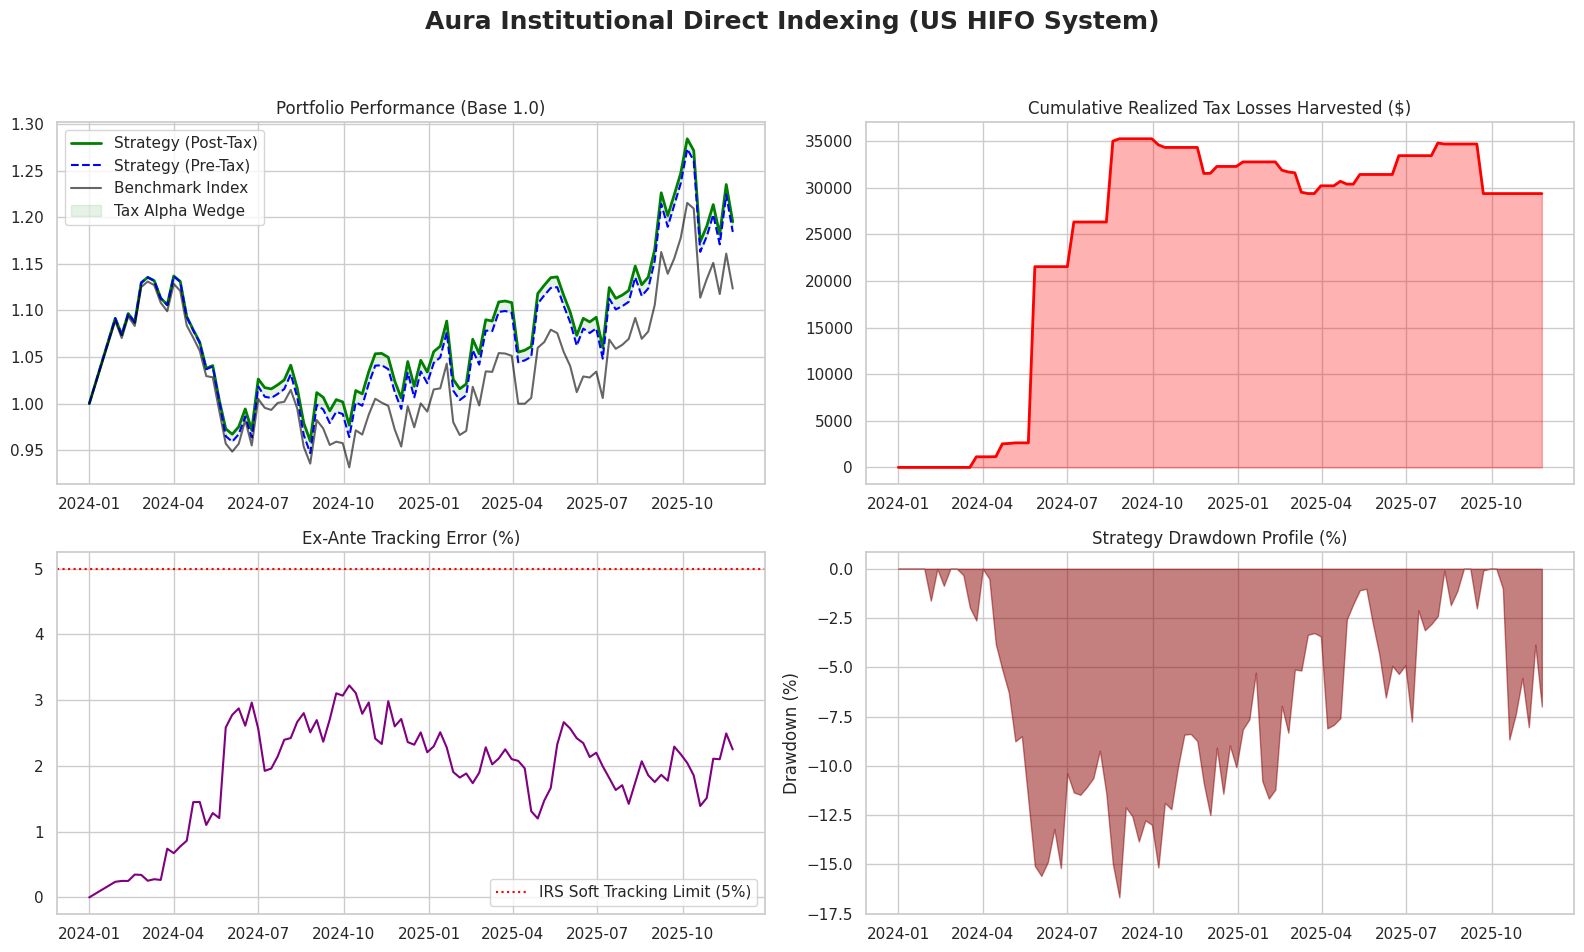

In [18]:
#USA

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os

# Set plotting style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. US TAX LEDGER (CASH + HIFO + ST/LT + WASH SALE)
# ==========================================

class TaxLot:
    def __init__(self, shares, price, date_idx):
        self.shares = shares
        self.price = price
        self.date_idx = date_idx

class USTaxLedger:
    def __init__(self, initial_cash=0.0):
        self.cash = initial_cash
        self.lots = defaultdict(list)
        self.realized_st_pnl = 0.0
        self.realized_lt_pnl = 0.0
        self.lockouts = defaultdict(int)

    def buy(self, ticker, shares_bought, price, current_step):
        if shares_bought <= 1e-6: return
        cost = shares_bought * price
        self.cash -= cost
        self.lots[ticker].append(TaxLot(shares_bought, price, current_step))

    def sell_hifo(self, ticker, shares_to_sell, current_price, current_step):
        if shares_to_sell <= 1e-6 or not self.lots[ticker]: return

        # HIFO Logic: Sort lots descending by price
        self.lots[ticker].sort(key=lambda x: x.price, reverse=True)

        remaining = shares_to_sell
        for lot in self.lots[ticker][:]:
            if remaining <= 1e-6: break

            sell_amt = min(lot.shares, remaining)
            pnl = sell_amt * (current_price - lot.price)

            if (current_step - lot.date_idx) < 252:
                self.realized_st_pnl += pnl
            else:
                self.realized_lt_pnl += pnl

            if pnl < 0:
                self.lockouts[ticker] = 30

            lot.shares -= sell_amt
            remaining -= sell_amt

            if lot.shares <= 1e-6:
                self.lots[ticker].remove(lot)

        self.cash += (shares_to_sell - remaining) * current_price

    def get_total_shares(self, ticker):
        return sum(lot.shares for lot in self.lots[ticker])

    def get_hifo_loss_percentage(self, ticker, current_price):
        if not self.lots[ticker]: return 0.0
        total_value = self.get_total_shares(ticker) * current_price
        if total_value == 0: return 0.0

        potential_loss = 0
        for lot in self.lots[ticker]:
            if lot.price > current_price:
                potential_loss += lot.shares * (lot.price - current_price)

        return potential_loss / total_value

    def update_lockouts(self, days_passed):
        for ticker in list(self.lockouts.keys()):
            if self.lockouts[ticker] > 0:
                self.lockouts[ticker] -= days_passed
                if self.lockouts[ticker] < 0:
                    self.lockouts[ticker] = 0

    def is_locked(self, ticker):
        return self.lockouts[ticker] > 0

# ==========================================
# 2. CONSTRAINED CONVEX OPTIMIZER
# ==========================================

class RobustOptimizer:
    def __init__(self, num_assets, lambda_tc=0.005, lambda_tax=0.15):
        self.N = num_assets
        self.lambda_tc = lambda_tc
        self.lambda_tax = lambda_tax

    def optimize(self, w_current, w_benchmark, cov_matrix, unrealized_losses, locked_flags):
        w = cp.Variable(self.N)
        cov_matrix = cov_matrix + np.eye(self.N) * 1e-6
        te_variance = cp.quad_form(w - w_benchmark, cov_matrix)

        delta_w = w - w_current
        turnover_penalty = self.lambda_tc * cp.norm(delta_w, 1)
        tax_incentive = self.lambda_tax * (unrealized_losses.T @ delta_w)

        objective = cp.Minimize(te_variance + turnover_penalty + tax_incentive)

        constraints =[
            cp.sum(w) == 1,
            w >= 0,
            cp.abs(w - w_benchmark) <= 0.05
        ]

        for i in range(self.N):
            if locked_flags[i]:
                constraints.append(w[i] <= w_current[i] + 1e-5)

        prob = cp.Problem(objective, constraints)

        try:
            prob.solve(solver=cp.OSQP)
            if w.value is None: return w_current
            return w.value
        except:
            return w_current

# ==========================================
# 3. METRICS TEAR-SHEET
# ==========================================

def calculate_drawdown(series):
    roll_max = series.cummax()
    return ((series - roll_max) / roll_max).min()

def print_metrics_tearsheet(df_history):
    print("\n" + "="*70)
    print(f"{'AURA INSTITUTIONAL METRICS TEAR-SHEET (US HIFO)':^70}")
    print("="*70)

    strat_pre_ret = df_history['pre_tax_val'].pct_change().dropna()
    strat_post_ret = df_history['post_tax_val'].pct_change().dropna()
    bench_ret = df_history['bench_val'].pct_change().dropna()

    ann_pre = (df_history['pre_tax_val'].iloc[-1] / df_history['pre_tax_val'].iloc[0]) - 1
    ann_post = (df_history['post_tax_val'].iloc[-1] / df_history['post_tax_val'].iloc[0]) - 1
    ann_bench = (df_history['bench_val'].iloc[-1] / df_history['bench_val'].iloc[0]) - 1

    # FIX: Annualization factor for weekly steps (252 / 5)
    ann_factor = np.sqrt(252 / 5)
    vol_pre = strat_pre_ret.std() * ann_factor
    vol_post = strat_post_ret.std() * ann_factor
    vol_bench = bench_ret.std() * ann_factor

    rf = 0.02
    sharpe_pre = (ann_pre - rf) / vol_pre if vol_pre > 0 else 0
    sharpe_post = (ann_post - rf) / vol_post if vol_post > 0 else 0
    sharpe_bench = (ann_bench - rf) / vol_bench if vol_bench > 0 else 0

    dd_pre = calculate_drawdown(df_history['pre_tax_val'])
    dd_post = calculate_drawdown(df_history['post_tax_val'])
    dd_bench = calculate_drawdown(df_history['bench_val'])

    tracking_error = strat_pre_ret.sub(bench_ret).std() * ann_factor
    info_ratio = (ann_pre - ann_bench) / tracking_error if tracking_error > 0 else 0
    tax_alpha = ann_post - ann_pre

    # FIX: Guard against dividing by zero if benchmark variance is 0
    var_bench = np.var(bench_ret)
    beta = np.cov(strat_pre_ret, bench_ret)[0][1] / var_bench if var_bench > 0 else 1.0

    print(f"{'Metric':<25} | {'Benchmark':<12} | {'Strategy (Pre)':<14} | {'Strategy (Post)':<14}")
    print("-" * 70)
    print(f"{'Total Return':<25} | {ann_bench*100:>11.2f}% | {ann_pre*100:>13.2f}% | {ann_post*100:>13.2f}%")
    print(f"{'Annualized Volatility':<25} | {vol_bench*100:>11.2f}% | {vol_pre*100:>13.2f}% | {vol_post*100:>13.2f}%")
    print(f"{'Sharpe Ratio':<25} | {sharpe_bench:>11.2f}  | {sharpe_pre:>13.2f}  | {sharpe_post:>13.2f} ")
    print(f"{'Max Drawdown':<25} | {dd_bench*100:>11.2f}% | {dd_pre*100:>13.2f}% | {dd_post*100:>13.2f}%")
    print("-" * 70)
    print(f"{'Tax Alpha Generated':<25} | {'-':>12} | {'-':>14} | {tax_alpha*100:>13.2f}%")
    print(f"{'Realized Tracking Error':<25} | {'-':>12} | {tracking_error*100:>13.2f}% | {'-':>14}")
    print(f"{'Beta to Benchmark':<25} | {'1.00':>12} | {beta:>13.2f}  | {'-':>14}")
    print(f"{'Information Ratio':<25} | {'-':>12} | {info_ratio:>13.2f}  | {'-':>14}")
    print("="*70 + "\n")

# ==========================================
# 4. SIMULATION ENGINE
# ==========================================

def run_simulation_and_plot():
    np.random.seed(101)
    days, num_assets = 500, 10
    dates = pd.date_range(start="2024-01-01", periods=days, freq="B")

    market_return = np.random.normal(0.0003, 0.012, days)
    market_return[50:100] -= 0.004

    asset_returns = np.zeros((days, num_assets))
    for i in range(num_assets):
        asset_returns[:, i] = np.random.uniform(0.7, 1.3) * market_return + np.random.normal(0, 0.01, days)

    prices = 100 * np.exp(np.cumsum(asset_returns, axis=0))
    df_prices = pd.DataFrame(prices, index=dates, columns=[f"STK_{i}" for i in range(num_assets)])

    # FIX: Bypass Pandas index alignment by passing the raw numpy array calculation directly
    df_prices['Benchmark'] = 100 * (1 + asset_returns.mean(axis=1)).cumprod()

    tickers =[c for c in df_prices.columns if c != 'Benchmark']
    N = len(tickers)
    w_benchmark = np.ones(N) / N

    initial_capital = 1_000_000
    ledger = USTaxLedger(initial_cash=initial_capital)
    opt = RobustOptimizer(num_assets=N, lambda_tc=0.005, lambda_tax=0.5)

    initial_prices = df_prices[tickers].iloc[0].values
    for i, ticker in enumerate(tickers):
        ledger.buy(ticker, (initial_capital * w_benchmark[i]) / initial_prices[i], initial_prices[i], 0)

    history = {
        'dates':[dates[0]], 'pre_tax_val': [initial_capital], 'post_tax_val':[initial_capital],
        'bench_val': [initial_capital], 'cum_losses':[0], 'tracking_errors': [0]
    }

    ST_RATE = 0.37
    LT_RATE = 0.20

    step_days = 5

    for step in range(20, len(df_prices), step_days):
        current_date, current_prices = df_prices.index[step], df_prices[tickers].iloc[step].values

        ledger.update_lockouts(step_days)
        locked_flags =[ledger.is_locked(t) for t in tickers]

        current_holdings_value = np.array([ledger.get_total_shares(t) * p for t, p in zip(tickers, current_prices)])
        portfolio_value = ledger.cash + np.sum(current_holdings_value)
        w_drifted = current_holdings_value / portfolio_value

        returns_window = df_prices[tickers].iloc[step-20:step].pct_change().dropna()
        cov_matrix = returns_window.cov().values * 252
        unrealized_losses = np.array([ledger.get_hifo_loss_percentage(t, p) for t, p in zip(tickers, current_prices)])

        w_target = opt.optimize(w_drifted, w_benchmark, cov_matrix, unrealized_losses, locked_flags)

        for i, ticker in enumerate(tickers):
            target_value, current_value = portfolio_value * w_target[i], ledger.get_total_shares(ticker) * current_prices[i]
            if target_value - current_value < -100:
                ledger.sell_hifo(ticker, abs(target_value - current_value) / current_prices[i], current_prices[i], step)

        for i, ticker in enumerate(tickers):
            target_value, current_value = portfolio_value * w_target[i], ledger.get_total_shares(ticker) * current_prices[i]
            diff = target_value - current_value
            if diff > 100 and not locked_flags[i]:
                shares_to_buy = min(diff, ledger.cash) / current_prices[i]
                ledger.buy(ticker, shares_to_buy, current_prices[i], step)

        bench_return = df_prices['Benchmark'].iloc[step] / df_prices['Benchmark'].iloc[0]
        te = np.sqrt(np.clip(np.dot((w_target - w_benchmark).T, np.dot(cov_matrix, (w_target - w_benchmark))), 0, None))

        current_holdings_value = np.array([ledger.get_total_shares(t) * p for t, p in zip(tickers, current_prices)])
        final_pre_tax_value = ledger.cash + np.sum(current_holdings_value)

        st_savings = abs(ledger.realized_st_pnl) * ST_RATE if ledger.realized_st_pnl < 0 else 0
        lt_savings = abs(ledger.realized_lt_pnl) * LT_RATE if ledger.realized_lt_pnl < 0 else 0
        total_tax_savings = st_savings + lt_savings

        total_realized_loss = (abs(ledger.realized_st_pnl) if ledger.realized_st_pnl < 0 else 0) + \
                              (abs(ledger.realized_lt_pnl) if ledger.realized_lt_pnl < 0 else 0)

        history['dates'].append(current_date)
        history['pre_tax_val'].append(final_pre_tax_value)
        history['post_tax_val'].append(final_pre_tax_value + total_tax_savings)
        history['bench_val'].append(initial_capital * bench_return)
        history['cum_losses'].append(total_realized_loss)
        history['tracking_errors'].append(te)

    df_results = pd.DataFrame(history).set_index('dates')
    print_metrics_tearsheet(df_results)

    # --- VISUALIZATIONS ---
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('Aura Institutional Direct Indexing (US HIFO System)', fontsize=18, fontweight='bold')

    ax1 = plt.subplot(2, 2, 1)
    ax1.plot(df_results.index, df_results['post_tax_val'] / initial_capital, label='Strategy (Post-Tax)', color='green', linewidth=2)
    ax1.plot(df_results.index, df_results['pre_tax_val'] / initial_capital, label='Strategy (Pre-Tax)', color='blue', linestyle='--')
    ax1.plot(df_results.index, df_results['bench_val'] / initial_capital, label='Benchmark Index', color='black', alpha=0.6)
    ax1.fill_between(df_results.index, df_results['pre_tax_val']/initial_capital, df_results['post_tax_val']/initial_capital, color='green', alpha=0.1, label='Tax Alpha Wedge')
    ax1.set_title('Portfolio Performance (Base 1.0)')
    ax1.legend()

    ax2 = plt.subplot(2, 2, 2)
    ax2.fill_between(df_results.index, 0, df_results['cum_losses'], color='red', alpha=0.3)
    ax2.plot(df_results.index, df_results['cum_losses'], color='red', linewidth=2)
    ax2.set_title('Cumulative Realized Tax Losses Harvested ($)')

    ax3 = plt.subplot(2, 2, 3)
    ax3.plot(df_results.index, df_results['tracking_errors'] * 100, color='purple')
    ax3.axhline(y=5, color='red', linestyle=':', label='IRS Soft Tracking Limit (5%)')
    ax3.set_title('Ex-Ante Tracking Error (%)')
    ax3.legend()

    ax4 = plt.subplot(2, 2, 4)
    drawdowns = (df_results['pre_tax_val'] - df_results['pre_tax_val'].cummax()) / df_results['pre_tax_val'].cummax()
    ax4.fill_between(df_results.index, 0, drawdowns * 100, color='darkred', alpha=0.5)
    ax4.set_title('Strategy Drawdown Profile (%)')
    ax4.set_ylabel('Drawdown (%)')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    os.makedirs('img', exist_ok=True)
    plt.savefig('img/us_dashboard.png', dpi=300)
    print("\n[INFO] Dashboard image successfully saved to 'img/us_dashboard.png'")
    plt.show()

if __name__ == "__main__":
    run_simulation_and_plot()